In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Modello di crescita esponenziale o Modello di Malthus

In [3]:
def MalthusModel(birth_rate, death_rate, initial_population):
    return initial_population * (birth_rate - death_rate)

def ComuputeMalthusModel(birth_rate, death_rate, initial_population, num_iterations):
    population = initial_population
    y = []
    y.append(population)
    for i in range(num_iterations):
        new_population = population + MalthusModel(birth_rate, death_rate, population)
        y.append(new_population)
        population = new_population

    return y

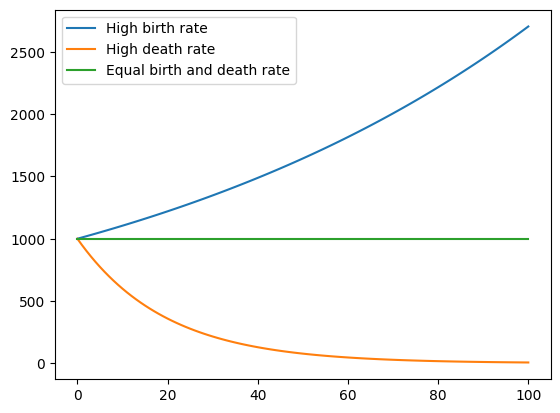

In [4]:
x0 = 1000
num_iterations = 100

y_top = ComuputeMalthusModel(0.05, 0.04, x0, num_iterations)
y_low = ComuputeMalthusModel(0.05, 0.1, x0, num_iterations)
y_mid = ComuputeMalthusModel(0.1, 0.1, x0, num_iterations)

plt.plot(y_top, label='High birth rate')
plt.plot(y_low, label='High death rate')
plt.plot(y_mid, label='Equal birth and death rate')
plt.legend()
plt.show()

### Modello (tumorale) di Malthus con influneza di trattamento terapeutico periodico

Modello event-triggered ovvero se la terapia agisce all'istante T_r subito dopo si vedrà il cambio di stato

In [5]:
def MalthusModel_therapy(birth_rate, death_rate, initial_population, therapy_coefficent):
    return initial_population * (birth_rate - death_rate - therapy_coefficent) 

def ComuputeMalthusModel_therapy(birth_rate, death_rate, initial_population, num_iterations, therapy_start, therapy_coefficent):
    population = initial_population
    y = []
    y.append(population)
    for i in range(num_iterations):
        if i % therapy_start == 0 and i != 0:
            new_population = population + MalthusModel_therapy(birth_rate, death_rate, population, therapy_coefficent)
        else:
            new_population = population + MalthusModel(birth_rate, death_rate, population)

        y.append(new_population)
        population = new_population

    return y

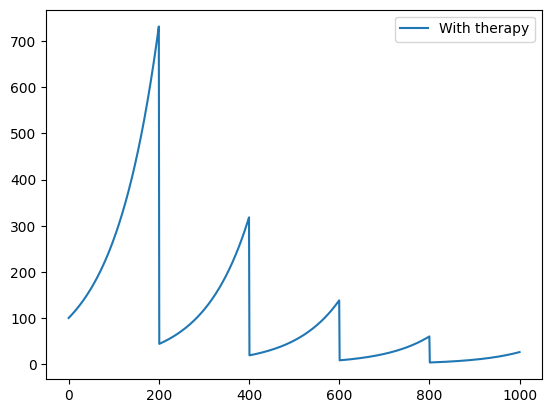

In [8]:
x0 = 100
num_iterations = 1000
therapy_theta = 0.95

y_therapy = ComuputeMalthusModel_therapy(0.05, 0.04, x0, num_iterations, 200, therapy_theta)

plt.plot(y_therapy, label='With therapy')

plt.legend()
plt.show()

### Modello di Malthus in cui b ed m sono funzioni della popolazione